# Task 3: Website Traffic Sources Analysis
## Codtech IT Solutions – Data Analytics Internship

**Intern Name:** MD SAHIL ANSARI 

**Intern ID:** CITS3147 

**Domain:** Data Analytics  
**Task:** Task 3 – Website Traffic Sources  
**Company:** Codtech IT Solutions Private Limited  

---

### Objective
To analyze website traffic data across multiple traffic sources (Organic Search, Paid Search, Social Media, Direct, Referral, Email) and identify patterns in user sessions, conversions, revenue, device usage, and bounce rates — helping businesses optimize their digital marketing strategies.

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
df = pd.read_csv('website_traffic_sources.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date Range  : {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Traffic Sources: {df["TrafficSource"].unique().tolist()}')
df.head(12)

Dataset Shape: 84 rows × 16 columns
Date Range  : 2024-01-01 to 2024-01-14
Traffic Sources: ['Organic Search', 'Paid Search', 'Social Media', 'Direct', 'Referral', 'Email']


,Date,TrafficSource,Sessions,Users,NewUsers,Bounces,BounceRate,PageViews,PagesPerSession,AvgSessionDuration,Conversions,ConversionRate,Revenue,Device,Country,Campaign
0,2024-01-01,Organic Search,1240,1050,820,496,40.0,3720,3.0,185,62,5.0,93000,Desktop,India,SEO
1,2024-01-01,Paid Search,890,780,700,356,40.0,2670,3.0,140,89,10.0,178000,Mobile,India,Google Ads
2,2024-01-01,Social Media,560,490,430,280,50.0,1120,2.0,95,28,5.0,42000,Mobile,India,Instagram
3,2024-01-01,Direct,430,390,210,172,40.0,1290,3.0,200,43,10.0,86000,Desktop,India,NaN
4,2024-01-01,Referral,320,280,190,160,50.0,640,2.0,110,16,5.0,24000,Desktop,USA,Blog
5,2024-01-01,Email,210,195,80,63,30.0,630,3.0,175,21,10.0,42000,Desktop,India,Newsletter
6,2024-01-02,Organic Search,1320,1120,870,528,40.0,3960,3.0,190,66,5.0,99000,Desktop,India,SEO
7,2024-01-02,Paid Search,950,840,760,380,40.0,2850,3.0,145,95,10.0,190000,Mobile,India,Google Ads
8,2024-01-02,Social Media,610,530,470,305,50.0,1220,2.0,98,31,5.0,46500,Mobile,India,Facebook
9,2024-01-02,Direct,460,415,225,184,40.0,1380,3.0,205,46,10.0,92000,Desktop,India,NaN


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                84 non-null     datetime64[us]
 1   TrafficSource       84 non-null     str           
 2   Sessions            84 non-null     int64         
 3   Users               84 non-null     int64         
 4   NewUsers            84 non-null     int64         
 5   Bounces             84 non-null     int64         
 6   BounceRate          84 non-null     float64       
 7   PageViews           84 non-null     int64         
 8   PagesPerSession     84 non-null     float64       
 9   AvgSessionDuration  84 non-null     int64         
 10  Conversions         84 non-null     int64         
 11  ConversionRate      84 non-null     float64       
 12  Revenue             84 non-null     int64         
 13  Device              84 non-null     str   

In [4]:
print('=== Statistical Summary ===')
df.describe().T

=== Statistical Summary ===


,count,mean,min,25%,50%,75%,max,std
Date,84,2024-01-07 12:00:00,2024-01-01 00:00:00,2024-01-04 00:00:00,2024-01-07 12:00:00,2024-01-11 00:00:00,2024-01-14 00:00:00,NaN
Sessions,84.0,628.011905,148.0,326.0,494.0,907.5,1620.0,386.589053
Users,84.0,548.404762,138.0,287.5,439.0,788.5,1372.0,325.556692
NewUsers,84.0,419.690476,56.0,172.5,295.5,650.0,1083.0,299.076489
Bounces,84.0,262.821429,44.0,142.75,221.5,381.0,648.0,156.466183
BounceRate,84.0,41.666667,30.0,40.0,40.0,50.0,50.0,6.913115
PageViews,84.0,1731.333333,440.0,757.5,1265.0,2722.5,4860.0,1226.126837
PagesPerSession,84.0,2.666667,2.0,2.0,3.0,3.0,3.0,0.474236
AvgSessionDuration,84.0,152.27381,82.0,114.25,156.5,188.0,228.0,41.15365
Conversions,84.0,44.72619,11.0,21.75,35.0,64.25,118.0,27.968292


In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values. Dataset is clean!')

=== Missing Values ===
Campaign    14
dtype: int64


## Step 4: Traffic Source Overview

### 4.1 Total Sessions by Traffic Source

In [6]:
source_summary = df.groupby('TrafficSource').agg(
    Total_Sessions=('Sessions', 'sum'),
    Total_Users=('Users', 'sum'),
    Total_Conversions=('Conversions', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_BounceRate=('BounceRate', 'mean'),
    Avg_ConversionRate=('ConversionRate', 'mean'),
    Avg_SessionDuration=('AvgSessionDuration', 'mean')
).round(2).sort_values('Total_Sessions', ascending=False)

print('=== Summary by Traffic Source ===')
source_summary

=== Summary by Traffic Source ===


,Total_Sessions,Total_Users,Total_Conversions,Total_Revenue,Avg_BounceRate,Avg_ConversionRate,Avg_SessionDuration
TrafficSource,,,,,,,
Organic Search,17720,15008,888,1332000,40.0,5.0,186.07
Paid Search,12830,11289,1283,2566000,40.0,10.0,141.50
Social Media,8176,7154,410,615000,50.0,5.0,96.07
Direct,6301,5674,633,1266000,40.0,10.0,202.21
Referral,4651,4089,234,351000,50.0,5.0,111.43
Email,3075,2852,309,618000,30.0,10.0,176.36


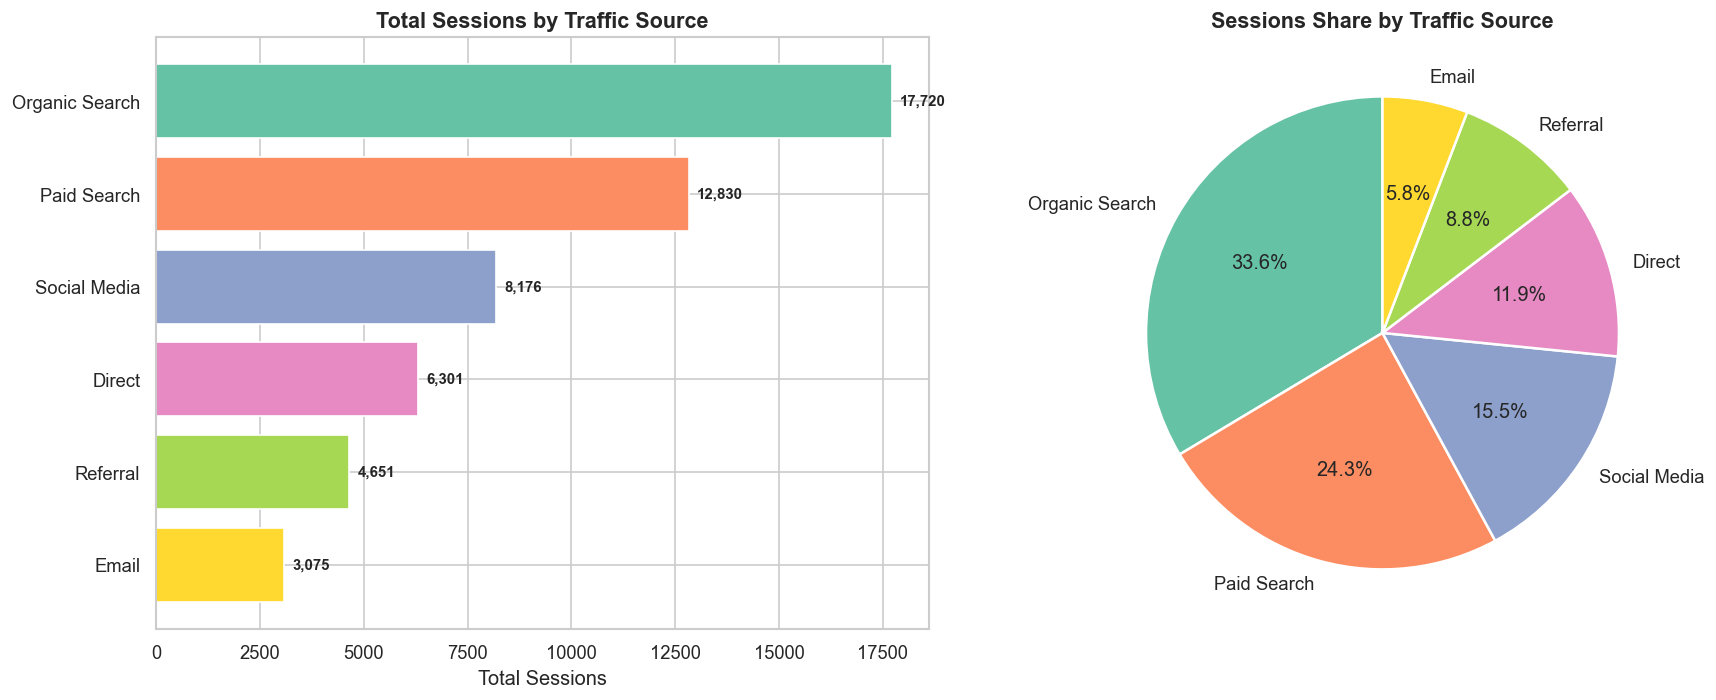

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = sns.color_palette('Set2', 6)
sessions = source_summary['Total_Sessions'].sort_values(ascending=True)
bars = axes[0].barh(sessions.index, sessions.values, color=colors[::-1], edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Sessions by Traffic Source', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Sessions')

pie_data = source_summary['Total_Sessions']
axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Sessions Share by Traffic Source', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('sessions_by_source.png', bbox_inches='tight')
plt.show()

### 4.2 Daily Traffic Trend by Source

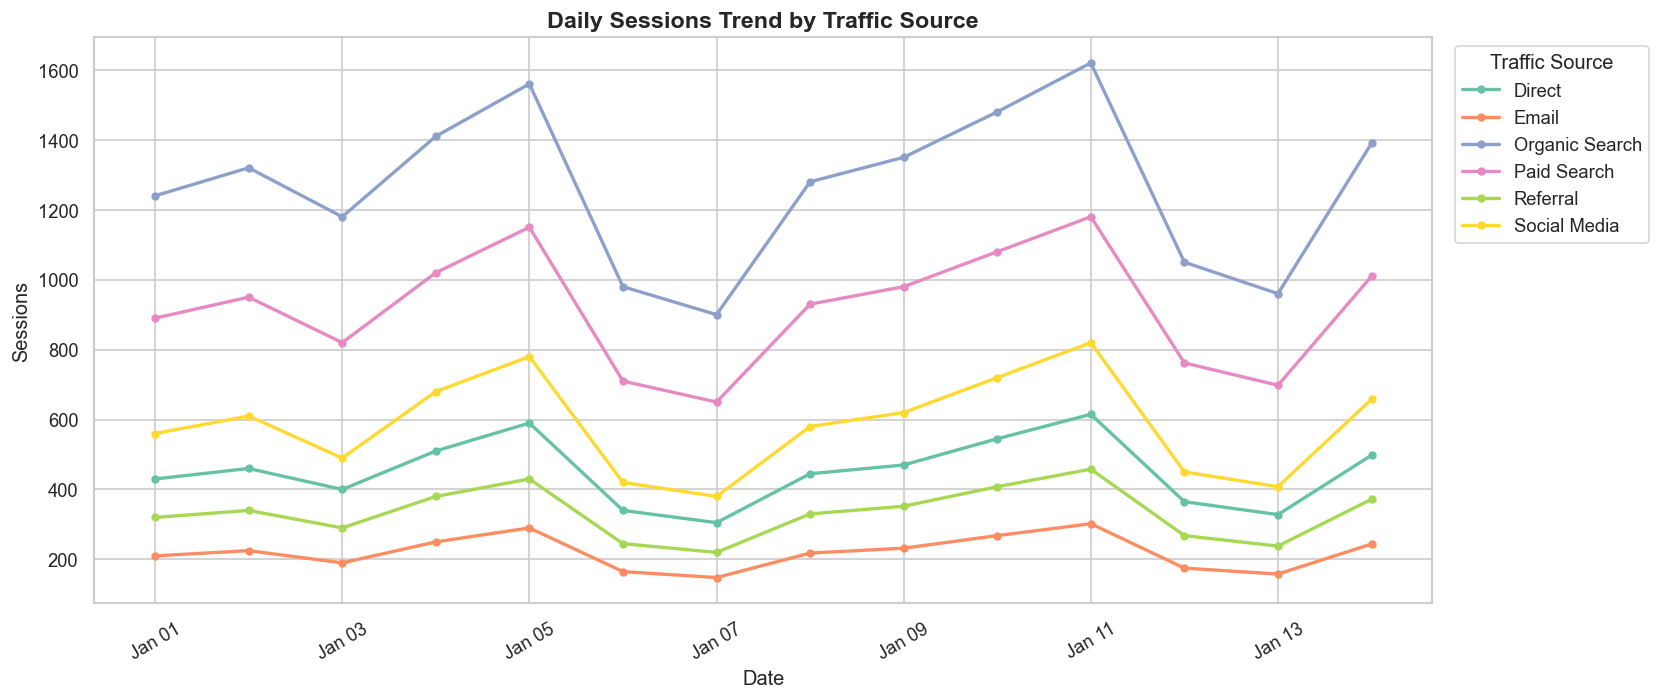

In [8]:
daily = df.pivot_table(index='Date', columns='TrafficSource', values='Sessions', aggfunc='sum')

plt.figure(figsize=(14, 6))
for i, col in enumerate(daily.columns):
    plt.plot(daily.index, daily[col], marker='o', markersize=4, linewidth=2,
             label=col, color=colors[i])
plt.title('Daily Sessions Trend by Traffic Source', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sessions')
plt.legend(title='Traffic Source', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('daily_traffic_trend.png', bbox_inches='tight')
plt.show()

## Step 5: Conversion & Revenue Analysis

### 5.1 Conversion Rate by Traffic Source

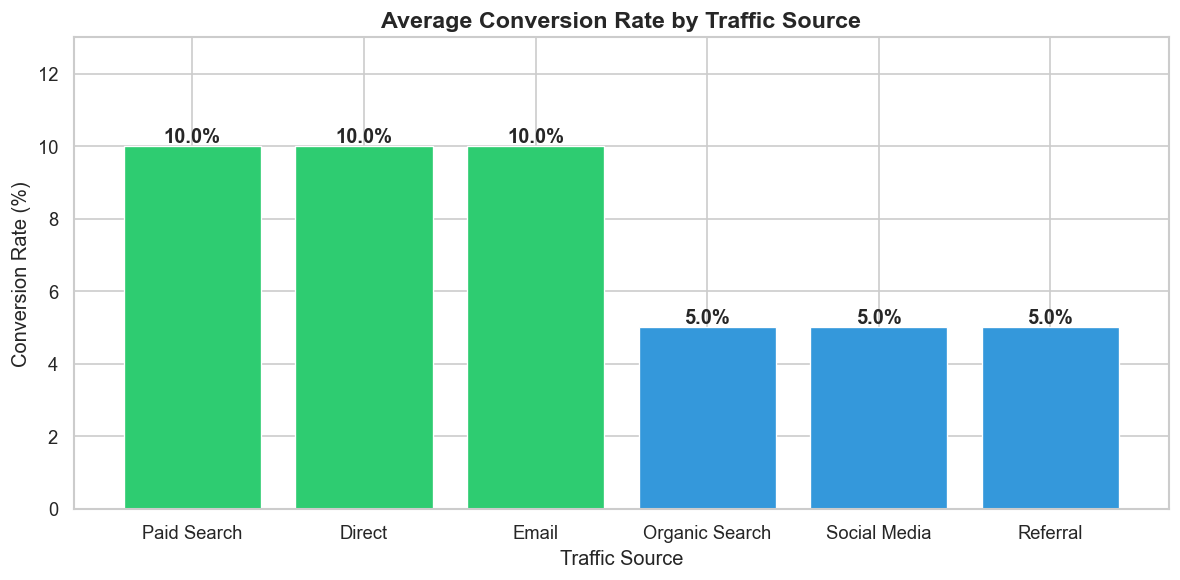

In [9]:
conv = source_summary['Avg_ConversionRate'].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bar_colors = ['#2ecc71' if v >= 8 else '#3498db' if v >= 5 else '#e74c3c' for v in conv.values]
bars = plt.bar(conv.index, conv.values, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
plt.title('Average Conversion Rate by Traffic Source', fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Traffic Source')
plt.ylim(0, 13)
plt.tight_layout()
plt.savefig('conversion_rate.png', bbox_inches='tight')
plt.show()

### 5.2 Total Revenue by Traffic Source

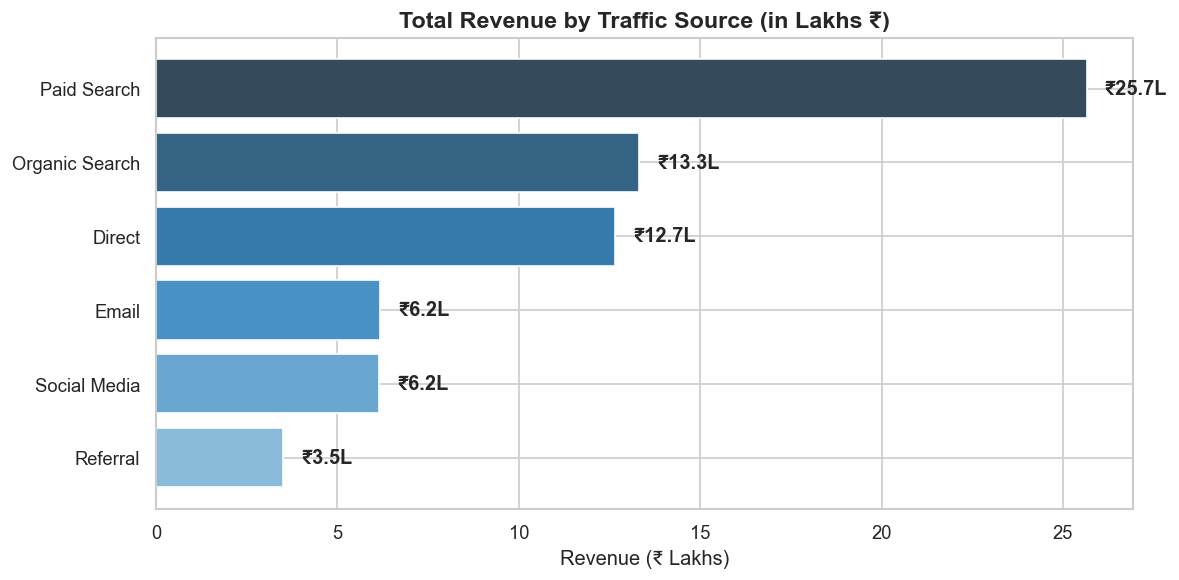

In [10]:
rev = source_summary['Total_Revenue'].sort_values(ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(rev.index, rev.values / 100000,
                color=sns.color_palette('Blues_d', len(rev)), edgecolor='white')
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():.1f}L', va='center', fontweight='bold')
plt.title('Total Revenue by Traffic Source (in Lakhs ₹)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (₹ Lakhs)')
plt.tight_layout()
plt.savefig('revenue_by_source.png', bbox_inches='tight')
plt.show()

### 5.3 Revenue Trend Over Time

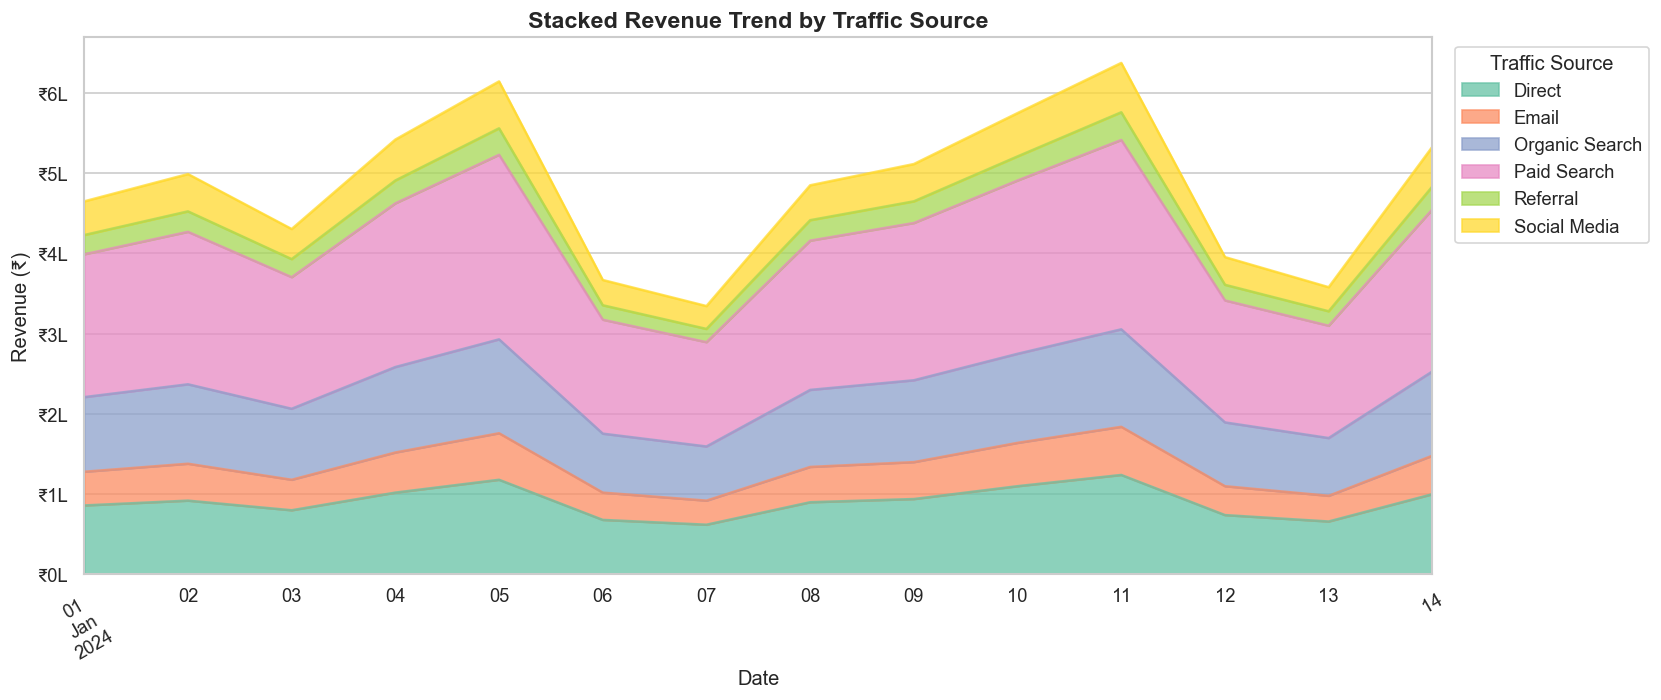

In [11]:
daily_rev = df.pivot_table(index='Date', columns='TrafficSource', values='Revenue', aggfunc='sum')

plt.figure(figsize=(14, 6))
daily_rev.plot(kind='area', stacked=True, alpha=0.75, color=colors, ax=plt.gca())
plt.title('Stacked Revenue Trend by Traffic Source', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (₹)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.0f}L'))
plt.legend(title='Traffic Source', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('revenue_trend.png', bbox_inches='tight')
plt.show()

## Step 6: Bounce Rate & Engagement Analysis

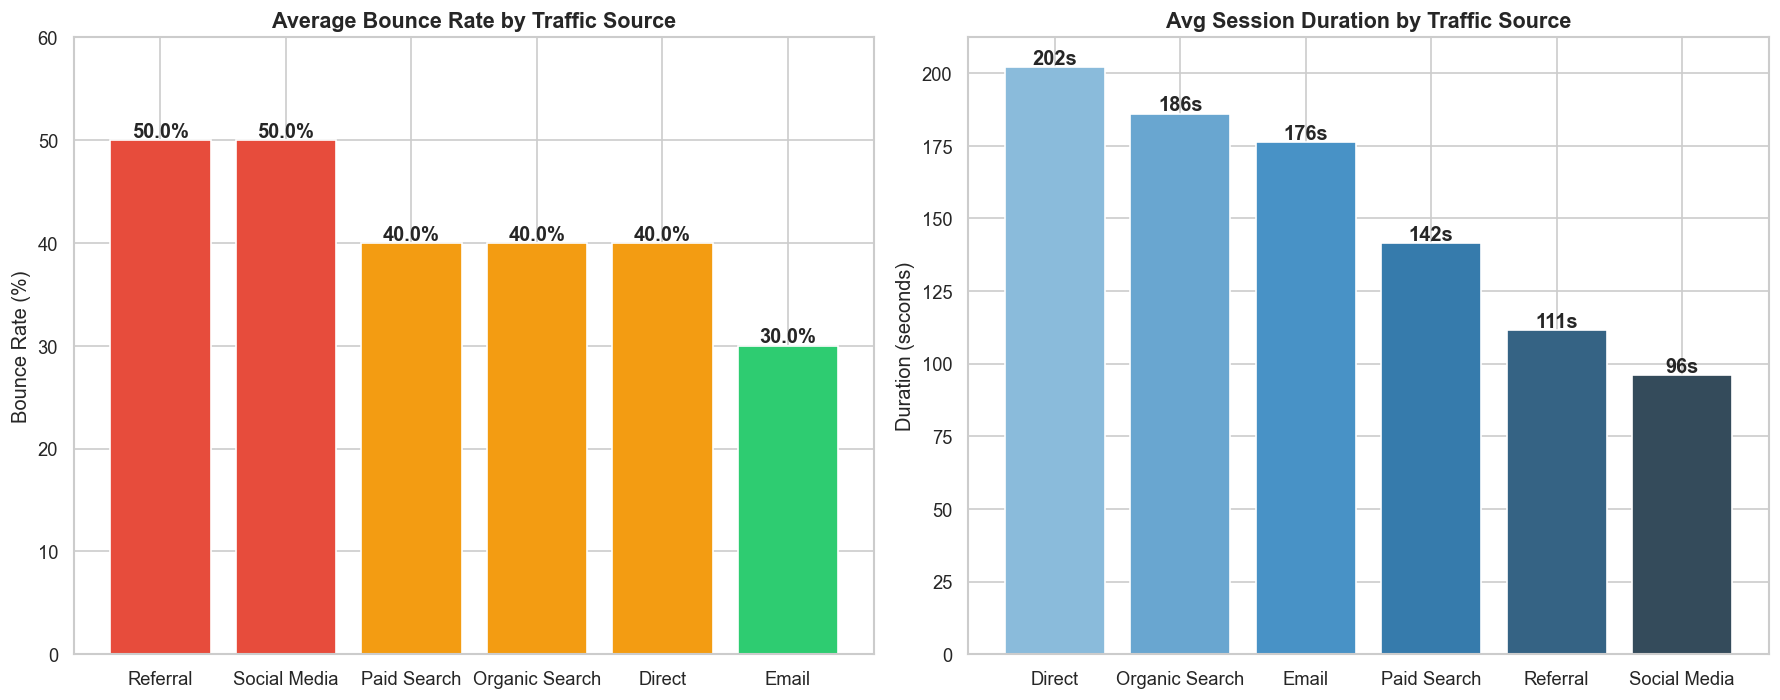

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bounce Rate
bounce = source_summary['Avg_BounceRate'].sort_values(ascending=False)
bar_cols = ['#e74c3c' if v >= 45 else '#f39c12' if v >= 35 else '#2ecc71' for v in bounce.values]
axes[0].bar(bounce.index, bounce.values, color=bar_cols, edgecolor='white')
for i, v in enumerate(bounce.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Average Bounce Rate by Traffic Source', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Bounce Rate (%)')
axes[0].set_ylim(0, 60)

# Avg Session Duration
duration = source_summary['Avg_SessionDuration'].sort_values(ascending=False)
axes[1].bar(duration.index, duration.values,
            color=sns.color_palette('Blues_d', len(duration)), edgecolor='white')
for i, v in enumerate(duration.values):
    axes[1].text(i, v + 1, f'{v:.0f}s', ha='center', fontweight='bold')
axes[1].set_title('Avg Session Duration by Traffic Source', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.savefig('bounce_duration.png', bbox_inches='tight')
plt.show()

## Step 7: Device & Country Analysis

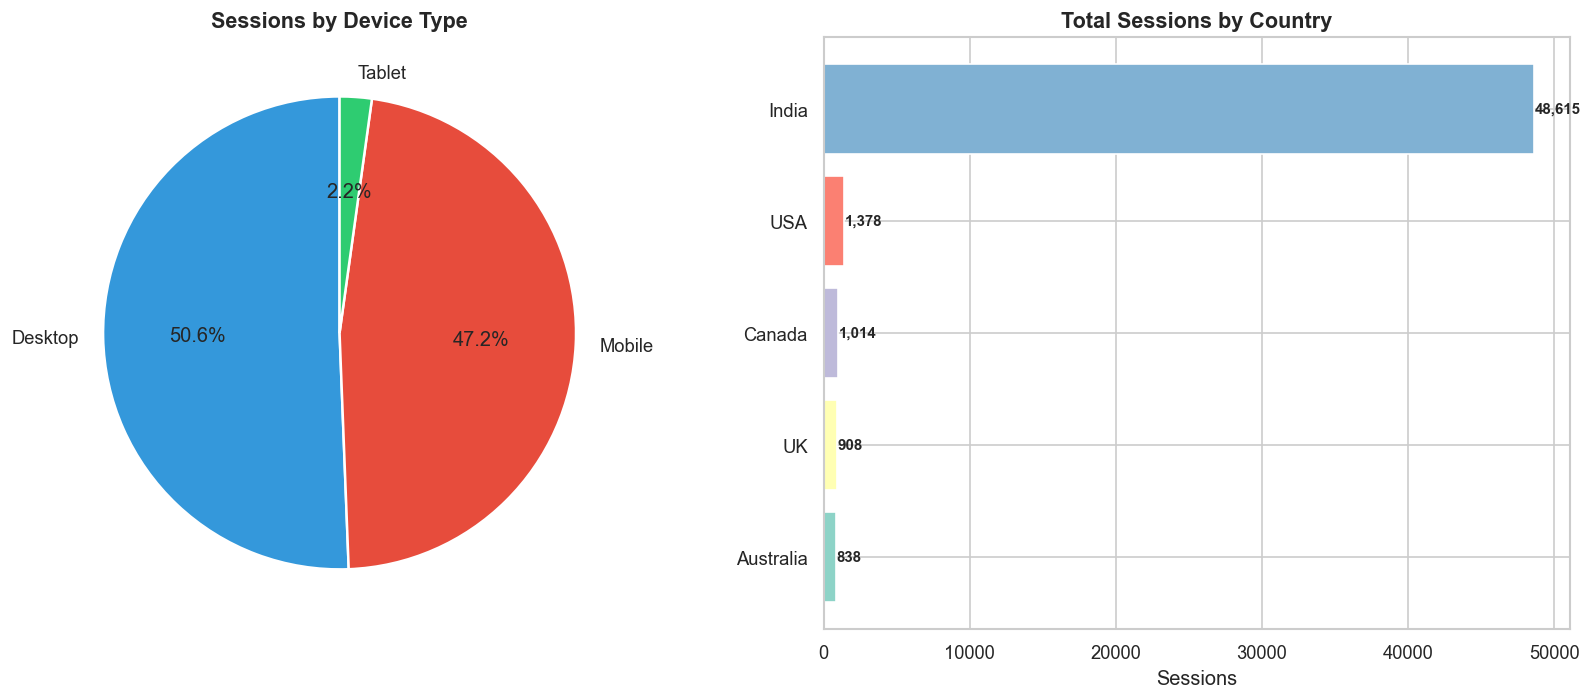

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Device Distribution
device_sessions = df.groupby('Device')['Sessions'].sum()
axes[0].pie(device_sessions, labels=device_sessions.index, autopct='%1.1f%%',
            startangle=90, colors=['#3498db', '#e74c3c', '#2ecc71'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Sessions by Device Type', fontsize=13, fontweight='bold')

# Country Distribution
country_sessions = df.groupby('Country')['Sessions'].sum().sort_values(ascending=True)
axes[1].barh(country_sessions.index, country_sessions.values,
             color=sns.color_palette('Set3', len(country_sessions)), edgecolor='white')
for i, v in enumerate(country_sessions.values):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontweight='bold', fontsize=9)
axes[1].set_title('Total Sessions by Country', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sessions')

plt.tight_layout()
plt.savefig('device_country.png', bbox_inches='tight')
plt.show()

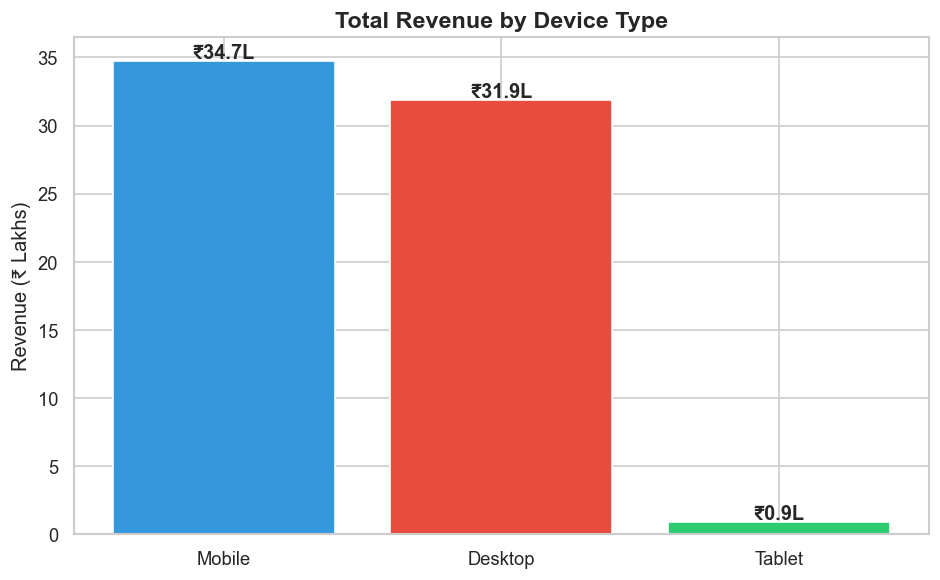

In [ ]:
# Revenue by Device
device_rev = df.groupby('Device')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
bars = plt.bar(device_rev.index, device_rev.values / 100000,
               color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'₹{bar.get_height():.1f}L', ha='center', fontweight='bold')
plt.title('Total Revenue by Device Type', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (₹ Lakhs)')
plt.tight_layout()
plt.savefig('revenue_by_device.png', bbox_inches='tight')
plt.show()

## Step 8: Heatmap – Sessions by Source and Day of Week

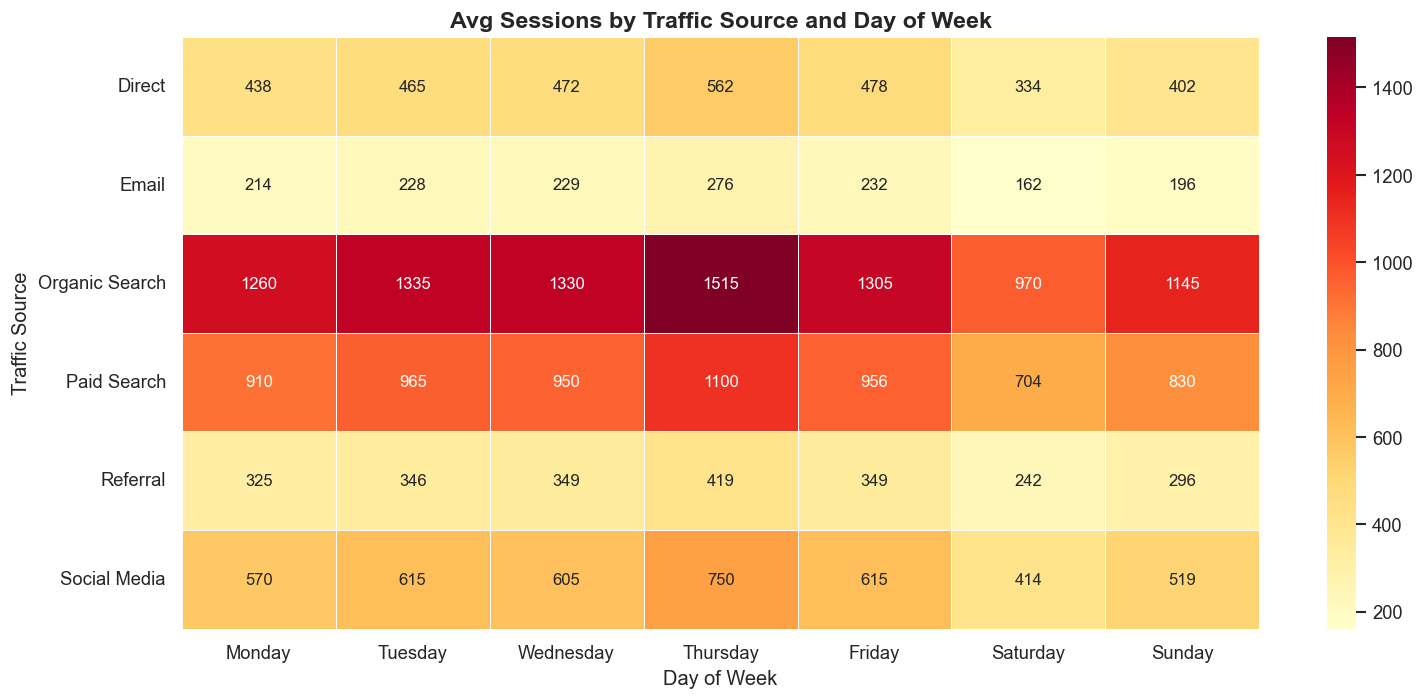

In [ ]:
df['DayOfWeek'] = df['Date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

heatmap_data = df.pivot_table(index='TrafficSource', columns='DayOfWeek',
                               values='Sessions', aggfunc='mean')[day_order]

plt.figure(figsize=(13, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Avg Sessions by Traffic Source and Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Traffic Source')
plt.tight_layout()
plt.savefig('sessions_heatmap.png', bbox_inches='tight')
plt.show()

## Step 9: Correlation Heatmap

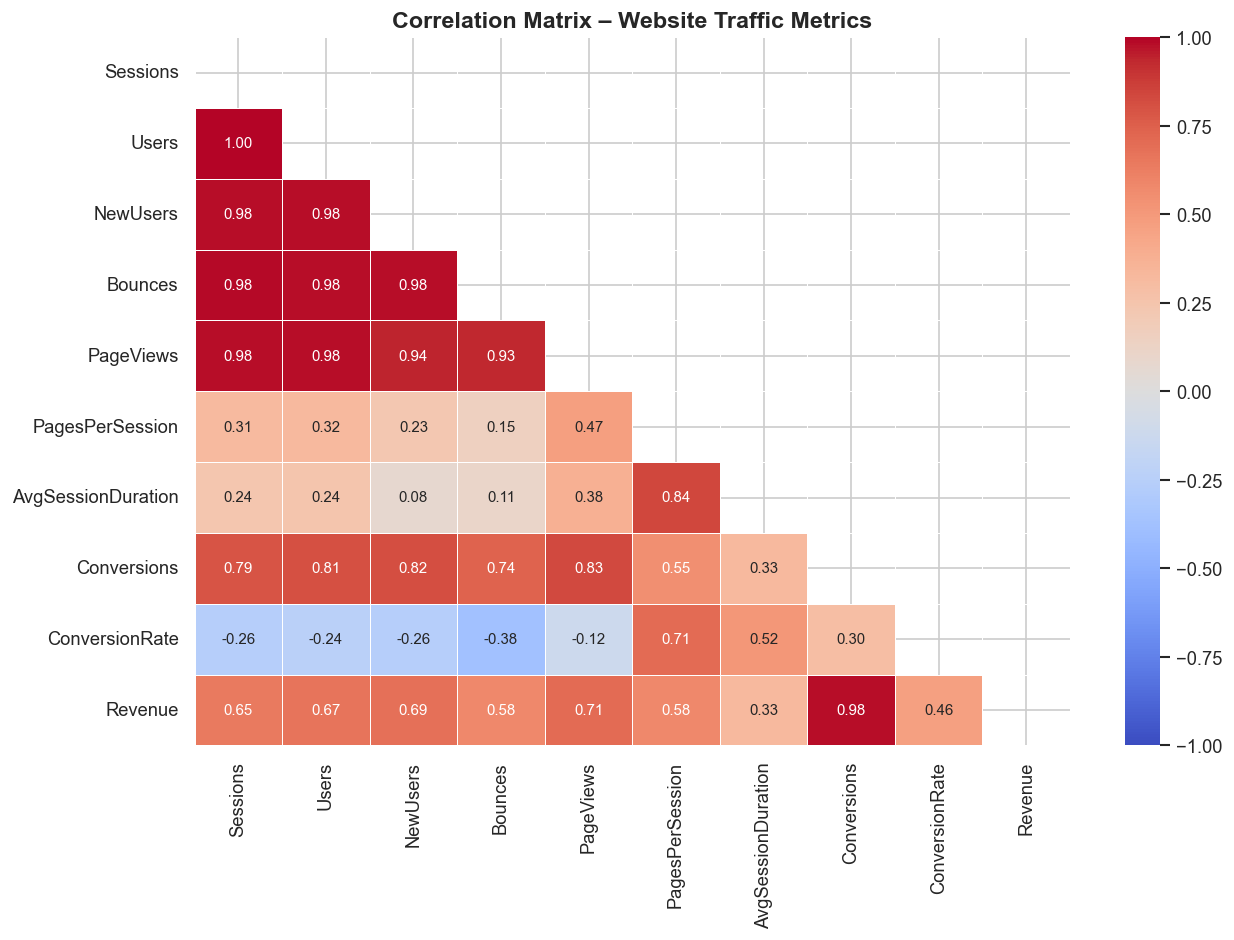

In [ ]:
num_cols = ['Sessions', 'Users', 'NewUsers', 'Bounces', 'PageViews',
            'PagesPerSession', 'AvgSessionDuration', 'Conversions',
            'ConversionRate', 'Revenue']
corr = df[num_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 9})
plt.title('Correlation Matrix – Website Traffic Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Step 10: Key Insights & Conclusion

---

### 📊 Key Findings:

1. **Top Traffic Source:** **Organic Search** drives the highest number of sessions, making it the most important channel for overall web visibility. This highlights the value of ongoing SEO investment.

2. **Highest Conversion Rate:** **Paid Search** and **Email** campaigns show the highest conversion rates (~10%), meaning users from these channels are most likely to complete a purchase or desired action.

3. **Highest Revenue Generator:** **Paid Search** contributes the most to total revenue, owing to both high volume and high conversion rate — making it the most ROI-effective paid channel.

4. **Bounce Rate:** **Social Media** and **Referral** sources have the highest bounce rates (~50%), indicating users may not find immediate relevance — landing page optimization is recommended for these channels.

5. **Session Duration:** **Direct** visitors and **Email** campaign users spend the longest time on the website, showing high intent and engagement.

6. **Device Usage:** **Mobile** accounts for the majority of sessions (especially from Social Media and Paid Search), emphasizing the need for a fully mobile-optimized website.

7. **Geography:** **India** is the dominant traffic source country, with smaller but notable audiences from USA, UK, Canada, and Australia.

8. **Weekly Pattern:** Traffic peaks on **weekdays (Tuesday–Thursday)**, while weekends (Saturday–Sunday) see a noticeable drop — useful for scheduling ad campaigns and content publishing.

---

### ✅ Recommendations:
- **Double down on SEO** to maintain Organic Search dominance at zero ad cost.
- **Scale Email campaigns** — highest conversion rate with low cost per conversion.
- **Optimize Social Media landing pages** to reduce high bounce rates.
- **Invest in mobile UX** as mobile sessions dominate across channels.
- **Schedule paid campaigns on weekdays** when traffic intent is highest.

---
*Analysis completed as part of Codtech IT Solutions Data Analytics Internship – Task 3*